<a href="https://colab.research.google.com/github/farid22022/Machine_Learning_From_Zero_to_Hero/blob/main/4_7Handle_imbalanced_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imbalanced Dataset

A dataset with an unequal class distribution

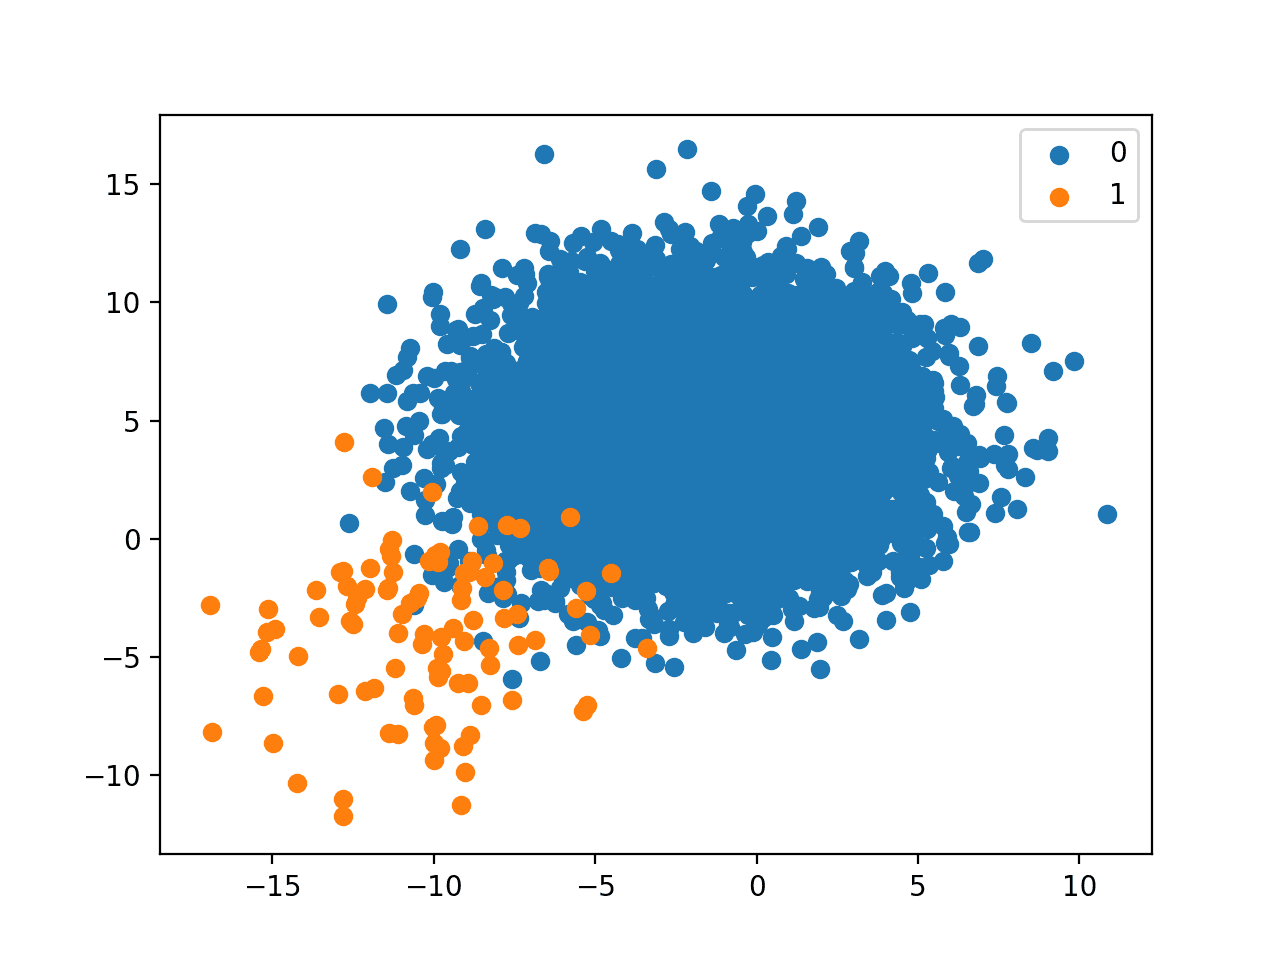

In [5]:
import numpy as np
import pandas as pd


In [7]:
credit_card_data = pd.read_csv('/content/credit_data.csv')

In [9]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [10]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
25833,33785,-0.187402,0.445507,2.199225,3.030535,-0.361376,1.095100,-0.119594,0.245950,-0.371890,...,0.154001,0.813468,0.377732,0.201209,-1.671394,-0.064077,0.067891,0.021521,42.33,0.0
25834,33785,1.237064,0.312096,0.191934,0.496764,-0.129777,-0.551625,-0.007160,-0.048880,-0.240393,...,-0.255114,-0.759423,0.072774,-0.035961,0.238605,0.096858,-0.025772,0.017772,1.79,0.0
25835,33785,1.245292,-0.594493,0.275982,-0.578346,-0.920599,-0.865570,-0.321689,-0.217249,-1.007295,...,0.303333,0.736260,-0.102900,0.452253,0.510125,-0.114928,0.003129,0.021850,70.75,0.0
25836,33787,-0.697373,0.401180,0.803750,-1.015524,-0.226100,0.283660,0.094868,0.077613,-1.327124,...,0.118688,0.467655,-0.162958,-0.703390,-0.174347,-0.202938,-0.369636,-0.152421,49.95,0.0
25837,33787,1.303469,0.498450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Distribution of the classes

In [11]:
credit_card_data['Class'].value_counts()

,count
Class,
0.0,25749
1.0,88


This is Highly Imbalanced Dataset



In [12]:
#Separating the legit and fraudulent
legit = credit_card_data[credit_card_data.Class == 0]
fradulent = credit_card_data[credit_card_data.Class == 1]

In [13]:
print(legit)

        Time        V1        V2        V3        V4        V5        V6  \
0          0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1          0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2          1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3          1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4          2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   
...      ...       ...       ...       ...       ...       ...       ...   
25832  33784  1.261980 -0.325252 -0.143104 -1.105445 -0.156888  0.006692   
25833  33785 -0.187402  0.445507  2.199225  3.030535 -0.361376  1.095100   
25834  33785  1.237064  0.312096  0.191934  0.496764 -0.129777 -0.551625   
25835  33785  1.245292 -0.594493  0.275982 -0.578346 -0.920599 -0.865570   
25836  33787 -0.697373  0.401180  0.803750 -1.015524 -0.226100  0.283660   

             V7        V8        V9  ...       V21       V22       V23  \
0      0.2395

In [14]:
legit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,...,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.000000,25749.0
mean,19380.491087,-0.197045,0.145743,0.767372,0.208854,-0.174420,0.088572,-0.100712,0.011278,0.453641,...,-0.039570,-0.131409,-0.038716,0.012076,0.128670,0.022883,0.010424,0.003824,75.726227,0.0
std,11662.244413,1.734655,1.485498,1.394098,1.382907,1.330924,1.313247,1.150915,1.263342,1.248965,...,0.814257,0.639990,0.523606,0.590011,0.430473,0.516955,0.389410,0.277878,219.488324,0.0
min,0.000000,-28.344757,-40.978852,-27.747084,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-4.532523,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-9.617915,0.000000,0.0
25%,7673.000000,-0.945115,-0.408337,0.284464,-0.687480,-0.774467,-0.657436,-0.591305,-0.164841,-0.377340,...,-0.249379,-0.551489,-0.173509,-0.324690,-0.133035,-0.339444,-0.065538,-0.008933,6.200000,0.0
50%,22722.000000,-0.264220,0.172738,0.865810,0.200665,-0.223393,-0.177508,-0.065987,0.028697,0.360405,...,-0.098314,-0.106557,-0.048917,0.063176,0.167058,-0.053428,0.006688,0.019847,18.960000,0.0
75%,30239.000000,1.167064,0.810197,1.492085,1.100325,0.321392,0.469391,0.447789,0.284447,1.203209,...,0.070683,0.276554,0.074687,0.399557,0.409561,0.303820,0.090375,0.076218,67.500000,0.0
max,33787.000000,1.960497,14.845545,4.101716,13.143668,34.099309,22.529298,36.677268,17.573712,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,4.860769,7879.420000,0.0


In [15]:
legit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [16]:
print(legit.shape)

(25749, 31)


In [17]:
print(fradulent.shape)

(88, 31)


Under_sampling

Build a sample dataset caontainig similiar

Distribution of fradulent and Legit

In [19]:
legit_sample = legit.sample(n=88)

Concate the sample

In [20]:
new_dataset = pd.concat([legit_sample,fradulent],axis=0)

In [21]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
23406,32738,1.277295,0.063755,-1.310409,-0.050431,2.246148,3.295564,-0.345013,0.761337,-0.154703,...,-0.018383,-0.181933,-0.145394,1.004608,0.843544,-0.314089,0.014084,0.015594,16.00,0.0
15564,26959,-0.862881,0.741690,1.270910,1.410720,1.921555,-0.952350,1.160395,-0.396763,-1.506737,...,0.069499,0.132407,-0.255953,-0.103191,0.268569,-0.119700,-0.129097,-0.095274,2.04,0.0
22976,32528,1.191085,0.538541,-0.580802,0.709803,0.333490,-0.668293,0.212136,-0.017419,-0.390733,...,-0.077775,-0.180837,-0.063470,-0.101127,0.459280,0.382182,-0.019734,0.028698,0.76,0.0
19224,30105,1.262341,0.138695,-0.026043,-0.110319,-0.101146,-0.799157,0.244307,-0.171252,-0.355243,...,-0.404398,-1.258377,0.142481,0.014943,0.121888,0.623700,-0.104902,-0.007499,16.98,0.0
1405,1085,0.985940,-0.294685,1.133313,1.474096,-1.065535,-0.234097,-0.457073,0.062174,0.754897,...,0.176458,0.455916,-0.166385,0.410243,0.460743,-0.251661,0.048013,0.051577,99.00,0.0


In [22]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
18773,29753,0.269614,3.549755,-5.810353,5.809370,1.538808,-2.269219,-0.824203,0.351070,-3.759059,...,0.371121,-0.322290,-0.549856,-0.520629,1.378210,0.564714,0.553255,0.402400,0.68,1.0
18809,29785,0.923764,0.344048,-2.880004,1.721680,-3.019565,-0.639736,-3.801325,1.299096,0.864065,...,0.899931,1.481271,0.725266,0.176960,-1.815638,-0.536517,0.489035,-0.049729,30.30,1.0
20198,30852,-2.830984,0.885657,1.199930,2.861292,0.321669,0.289966,1.767760,-2.451050,0.069736,...,0.546589,0.334971,0.172106,0.623590,-0.527114,-0.079215,-2.532445,0.311177,104.81,1.0
23308,32686,0.287953,1.728735,-1.652173,3.813544,-1.090927,-0.984745,-2.202318,0.555088,-2.033892,...,0.262202,-0.633528,0.092891,0.187613,0.368708,-0.132474,0.576561,0.309843,0.00,1.0
23422,32745,-2.179135,0.020218,-2.182733,2.572046,-3.663733,0.081568,0.268049,0.660437,-2.374027,...,1.026421,0.299614,1.656800,0.328433,0.106457,0.691775,0.196779,0.241085,717.15,1.0


In [23]:
new_dataset['Class'].value_counts()

,count
Class,
0.0,88
1.0,88
